In [ ]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('heart_disease_diagnosis.csv')

In [ ]:
df.head()





,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,capture_date
0,No,32.12,Yes,No,No,0.0,0.0,Yes,Female,80 or older,White,No,No,Good,9.0,No,No,Yes,2020-01-01
1,No,28.25,No,No,No,0.0,14.0,No,Female,60-64,White,No,Yes,Very good,6.0,No,No,No,2020-01-01
2,No,28.37,No,No,No,0.0,0.0,No,Male,55-59,White,No,Yes,Good,6.0,No,No,No,2020-01-01
3,No,24.39,No,No,No,0.0,0.0,No,Male,75-79,White,No,Yes,Excellent,4.0,No,No,Yes,2020-01-01
4,No,20.36,No,No,No,0.0,0.0,No,Female,50-54,White,No,Yes,Excellent,8.0,No,No,No,2020-01-01


In [ ]:
df = df.drop_duplicates()
df = df.dropna()
df.head()



,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,capture_date
0,No,32.12,Yes,No,No,0.0,0.0,Yes,Female,80 or older,White,No,No,Good,9.0,No,No,Yes,2020-01-01
1,No,28.25,No,No,No,0.0,14.0,No,Female,60-64,White,No,Yes,Very good,6.0,No,No,No,2020-01-01
2,No,28.37,No,No,No,0.0,0.0,No,Male,55-59,White,No,Yes,Good,6.0,No,No,No,2020-01-01
3,No,24.39,No,No,No,0.0,0.0,No,Male,75-79,White,No,Yes,Excellent,4.0,No,No,Yes,2020-01-01
4,No,20.36,No,No,No,0.0,0.0,No,Female,50-54,White,No,Yes,Excellent,8.0,No,No,No,2020-01-01


In [ ]:
# Convert 'AgeCategory' to numeric by mapping each category to its median value,

age_map = {
    '18-24': 21,   
    '25-29': 27,
    '30-34': 32,
    '35-39': 37,
    '40-44': 42,
    '45-49': 47,
    '50-54': 52,
    '55-59': 57,
    '60-64': 62,
    '65-69': 67,
    '70-74': 72,
    '75-79': 77,
    '80 or older': 82  
}
df['AgeNumeric'] = df['AgeCategory'].map(age_map)
df.head()


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,capture_date,AgeNumeric
0,No,32.12,Yes,No,No,0.0,0.0,Yes,Female,80 or older,White,No,No,Good,9.0,No,No,Yes,2020-01-01,82
1,No,28.25,No,No,No,0.0,14.0,No,Female,60-64,White,No,Yes,Very good,6.0,No,No,No,2020-01-01,62
2,No,28.37,No,No,No,0.0,0.0,No,Male,55-59,White,No,Yes,Good,6.0,No,No,No,2020-01-01,57
3,No,24.39,No,No,No,0.0,0.0,No,Male,75-79,White,No,Yes,Excellent,4.0,No,No,Yes,2020-01-01,77
4,No,20.36,No,No,No,0.0,0.0,No,Female,50-54,White,No,Yes,Excellent,8.0,No,No,No,2020-01-01,52


In [ ]:
df['BMI_Age_Risk'] = df['BMI'] * df['AgeNumeric']
df.head()


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,...,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,capture_date,AgeNumeric,BMI_Age_Risk
0,No,32.12,Yes,No,No,0.0,0.0,Yes,Female,80 or older,...,No,No,Good,9.0,No,No,Yes,2020-01-01,82,2633.84
1,No,28.25,No,No,No,0.0,14.0,No,Female,60-64,...,No,Yes,Very good,6.0,No,No,No,2020-01-01,62,1751.50
2,No,28.37,No,No,No,0.0,0.0,No,Male,55-59,...,No,Yes,Good,6.0,No,No,No,2020-01-01,57,1617.09
3,No,24.39,No,No,No,0.0,0.0,No,Male,75-79,...,No,Yes,Excellent,4.0,No,No,Yes,2020-01-01,77,1878.03
4,No,20.36,No,No,No,0.0,0.0,No,Female,50-54,...,No,Yes,Excellent,8.0,No,No,No,2020-01-01,52,1058.72


In [ ]:
from sklearn.cluster import KMeans

# Select features for clustering
cluster_features = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime', 'AgeNumeric']

# Fit KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
df['Patient_Profile_Cluster'] = kmeans.fit_predict(df[cluster_features])

# Convert numeric cluster labels to "Type 0", "Type 1", etc.
df['Patient_Profile_Cluster'] = df['Patient_Profile_Cluster'].apply(lambda x: f"Type {x}")

df.head()


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,...,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,capture_date,AgeNumeric,BMI_Age_Risk,Patient_Profile_Cluster
0,No,32.12,Yes,No,No,0.0,0.0,Yes,Female,80 or older,...,No,Good,9.0,No,No,Yes,2020-01-01,82,2633.84,Type 0
1,No,28.25,No,No,No,0.0,14.0,No,Female,60-64,...,Yes,Very good,6.0,No,No,No,2020-01-01,62,1751.50,Type 0
2,No,28.37,No,No,No,0.0,0.0,No,Male,55-59,...,Yes,Good,6.0,No,No,No,2020-01-01,57,1617.09,Type 1
3,No,24.39,No,No,No,0.0,0.0,No,Male,75-79,...,Yes,Excellent,4.0,No,No,Yes,2020-01-01,77,1878.03,Type 0
4,No,20.36,No,No,No,0.0,0.0,No,Female,50-54,...,Yes,Excellent,8.0,No,No,No,2020-01-01,52,1058.72,Type 1


In [ ]:

# Define column groups
numerical_columns = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime', 'BMI_Age_Risk']
ordinal_columns = ['AgeCategory', 'GenHealth']
nominal_columns = ['Race', 'Diabetic', 'Patient_Profile_Cluster']
binary_columns = ['Smoking', 'Sex', 'HeartDisease']  # HeartDisease is the target








In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

# For ordinal columns, define the ordering. Update GenHealth order as appropriate.
age_category_order = [
    '18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54',
    '55-59', '60-64', '65-69', '70-74', '75-79', '80 or older'
]
gen_health_order = ['Poor', 'Fair', 'Good', 'Very good', 'Excellent']

ordinal_categories = [age_category_order, gen_health_order]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('ord', OrdinalEncoder(categories=ordinal_categories), ordinal_columns),
        ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_columns),
    ]
)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Instead of df_encoded (which doesn't exist), use the actual df and preprocess it
# Encode 'HeartDisease' as 0 (No) and 1 (Yes)
df_bal = df.copy()
df_bal['HeartDisease'] = df_bal['HeartDisease'].map({'No': 0, 'Yes': 1})

# We'll drop columns that are non-numeric or not useful for training here
# Exclude columns like 'capture_date' if present
columns_to_drop = ['HeartDisease', 'capture_date'] if 'capture_date' in df_bal.columns else ['HeartDisease']
X = df_bal.drop(columns=columns_to_drop, axis=1)
y = df_bal['HeartDisease']

# 2. Split Data (80% Train, 20% Test) - stratify to preserve ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------------------------------------------------------
# BALANCE THE TRAINING DATA (Undersample majority class)
# ------------------------------------------------------------------------------

# Combine X and y for resampling
train_data = pd.concat([X_train, y_train], axis=1)

# Split into majority and minority
majority = train_data[train_data.HeartDisease == 0]
minority = train_data[train_data.HeartDisease == 1]

# Undersample majority to size of minority class
majority_downsampled = resample(
    majority,
    replace=False,
    n_samples=len(minority),
    random_state=42
)

# Combine
train_balanced = pd.concat([majority_downsampled, minority])

# Split back
X_train_balanced = train_balanced.drop('HeartDisease', axis=1)
y_train_balanced = train_balanced['HeartDisease']

print(f"Original Train Size: {len(X_train)} (Imbalanced)")
print(f"Balanced Train Size: {len(X_train_balanced)} (50% Healthy / 50% Sick)")

Original Train Size: 255805 (Imbalanced)
Balanced Train Size: 43796 (50% Healthy / 50% Sick)


In [ ]:

# Separate training data into "Healthy" (HeartDisease == 'No') and "Sick" (HeartDisease == 'Yes')
X_train_healthy = X_train[y_train == 'No']
X_train_sick = X_train[y_train == 'Yes']

y_train_healthy = y_train[y_train == 'No']
y_train_sick = y_train[y_train == 'Yes']

# Number of "Sick" and "Healthy" cases
n_sick = len(X_train_sick)
n_healthy = len(X_train_healthy)

# Only undersample if there are enough "Healthy" samples to match "Sick"; otherwise, sample all healthy
if n_healthy >= n_sick and n_sick > 0:
    # Randomly undersample "Healthy" cases to match number of "Sick" cases
    X_train_healthy_under = X_train_healthy.sample(n=n_sick, random_state=42)
    y_train_healthy_under = y_train_healthy.loc[X_train_healthy_under.index]
else:
    # Not enough "Healthy" samples to match "Sick" -- use all available "Healthy" samples
    X_train_healthy_under = X_train_healthy.copy()
    y_train_healthy_under = y_train_healthy.copy()

# Concatenate all "Sick" and undersampled "Healthy" cases
X_train_balanced = pd.concat([X_train_healthy_under, X_train_sick])
y_train_balanced = pd.concat([y_train_healthy_under, y_train_sick])

# Optional: Shuffle the resulting balanced training set
X_train_balanced, y_train_balanced = sklearn.utils.shuffle(X_train_balanced, y_train_balanced, random_state=42)



In [ ]:
# Display the entire modified dataset
from IPython.display import display

display(df)

# Optional: Save the modified dataset to a CSV file
df.to_csv("heart_modified_full.csv", index=False)
print("Full modified dataset saved as 'heart_modified_full.csv'.")


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,...,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,capture_date,AgeNumeric,BMI_Age_Risk,Patient_Profile_Cluster
0,No,32.12,Yes,No,No,0.0,0.0,Yes,Female,80 or older,...,No,Good,9.0,No,No,Yes,2020-01-01,82,2633.84,Type 0
1,No,28.25,No,No,No,0.0,14.0,No,Female,60-64,...,Yes,Very good,6.0,No,No,No,2020-01-01,62,1751.50,Type 0
2,No,28.37,No,No,No,0.0,0.0,No,Male,55-59,...,Yes,Good,6.0,No,No,No,2020-01-01,57,1617.09,Type 1
3,No,24.39,No,No,No,0.0,0.0,No,Male,75-79,...,Yes,Excellent,4.0,No,No,Yes,2020-01-01,77,1878.03,Type 0
4,No,20.36,No,No,No,0.0,0.0,No,Female,50-54,...,Yes,Excellent,8.0,No,No,No,2020-01-01,52,1058.72,Type 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,No,34.33,No,No,No,0.0,2.0,No,Female,30-34,...,Yes,Very good,8.0,No,No,No,2021-12-30,32,1098.56,Type 3
319791,No,20.73,No,No,No,0.0,15.0,No,Female,40-44,...,Yes,Excellent,7.0,Yes,No,No,2021-12-30,42,870.66,Type 1
319792,No,31.89,No,No,No,0.0,0.0,No,Female,35-39,...,No,Excellent,7.0,No,No,No,2021-12-30,37,1179.93,Type 3
319793,No,23.30,No,No,No,0.0,15.0,No,Female,70-74,...,Yes,Very good,6.0,No,No,No,2021-12-30,72,1677.60,Type 0


Full modified dataset saved as 'heart_modified_full.csv'.


In [ ]:
# Convert categorical columns in X_train using pandas.factorize
# (Assumes X_train and y_train are already defined from your train_test_split)

import numpy as np

# 1) Factorize all categorical columns in X_train
X_train_encoded = X_train.copy()

cat_cols = X_train_encoded.select_dtypes(include=["object", "category"]).columns
factorize_mappings = {}  # Optional: store mappings for interpretation later

for col in cat_cols:
    codes, uniques = pd.factorize(X_train_encoded[col])
    X_train_encoded[col] = codes
    factorize_mappings[col] = dict(enumerate(uniques))

print("Categorical columns factorized:", list(cat_cols))

# 2) Encode the target for SMOTE (e.g., 'No' -> 0, 'Yes' -> 1)

# If y_train is already numeric (0/1 from df_encoded), just copy it
if pd.api.types.is_numeric_dtype(y_train):
    y_train_encoded = y_train.astype(int)
else:
    # Map string labels 'No'/'Yes' -> 0/1 safely
    y_train_encoded = y_train.map({"No": 0, "Yes": 1})

    # Optional: check if any values were not mapped
    if y_train_encoded.isna().any():
        print("Warning: Unmapped target values found:")
        print(y_train[y_train_encoded.isna()].value_counts())

print("Target value counts (encoded):")
print(y_train_encoded.value_counts())

# 3) Create a fully numerical version of the original dataframe and save it

df_refined = df.copy()

for col in df_refined.select_dtypes(include=["object", "category"]).columns:
    if col == "HeartDisease":
        # Explicit mapping for clarity
        df_refined[col] = df_refined[col].map({"No": 0, "Yes": 1})
    else:
        df_refined[col], _ = pd.factorize(df_refined[col])

# Save the refined numeric dataset
output_path = "heart_refined_numeric.csv"
df_refined.to_csv(output_path, index=False)
print(f"Full refined numeric dataset saved to '{output_path}'.")

Categorical columns factorized: ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer', 'Patient_Profile_Cluster']
Target value counts (encoded):
HeartDisease
0    233907
1     21898
Name: count, dtype: int64
Full refined numeric dataset saved to 'heart_refined_numeric.csv'.


In [ ]:
import pandas as pd

# Load the refined numeric dataset
df_refined = pd.read_csv('heart_refined_numeric.csv')

# Display basic info about the dataset
print("Dataset shape:", df_refined.shape)
print("\nTarget variable distribution:")
print(df_refined['HeartDisease'].value_counts())
print("\nTarget variable distribution (percentage):")
print(df_refined['HeartDisease'].value_counts(normalize=True) * 100)

# Separate features and target
X = df_refined.drop('HeartDisease', axis=1)
y = df_refined['HeartDisease']

print(f"\nOriginal dataset - Class 0: {sum(y == 0)}, Class 1: {sum(y == 1)}")

Dataset shape: (319757, 22)

Target variable distribution:
HeartDisease
0    292385
1     27372
Name: count, dtype: int64

Target variable distribution (percentage):
HeartDisease
0    91.43975
1     8.56025
Name: proportion, dtype: float64

Original dataset - Class 0: 292385, Class 1: 27372


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# Step 1: Balance the dataset before splitting
# Combine X and y for resampling
df_balanced = pd.concat([X, y], axis=1)

# Separate majority and minority classes
majority_class = df_balanced[df_balanced['HeartDisease'] == 0]
minority_class = df_balanced[df_balanced['HeartDisease'] == 1]

print(f"Before balancing:")
print(f"  Class 0 (Majority): {len(majority_class)}")
print(f"  Class 1 (Minority): {len(minority_class)}")

# Undersample majority class to match minority class
majority_downsampled = resample(
    majority_class,
    replace=False,
    n_samples=len(minority_class),
    random_state=42
)

# Combine balanced classes
df_balanced = pd.concat([majority_downsampled, minority_class])

# Shuffle the balanced dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Separate features and target from balanced dataset
X_balanced = df_balanced.drop('HeartDisease', axis=1)
y_balanced = df_balanced['HeartDisease']

print(f"\nAfter balancing:")
print(f"  Class 0: {sum(y_balanced == 0)}")
print(f"  Class 1: {sum(y_balanced == 1)}")
print(f"  Total: {len(y_balanced)}")

Before balancing:
  Class 0 (Majority): 292385
  Class 1 (Minority): 27372

After balancing:
  Class 0: 27372
  Class 1: 27372
  Total: 54744


In [ ]:
# Step 2: Split the balanced dataset into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, 
    y_balanced, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_balanced  # Maintain class balance in both splits
)

print("Dataset split completed:")
print(f"\nTraining set:")
print(f"  Total samples: {len(X_train)}")
print(f"  Class 0: {sum(y_train == 0)} ({sum(y_train == 0)/len(y_train)*100:.2f}%)")
print(f"  Class 1: {sum(y_train == 1)} ({sum(y_train == 1)/len(y_train)*100:.2f}%)")

print(f"\nTest set:")
print(f"  Total samples: {len(X_test)}")
print(f"  Class 0: {sum(y_test == 0)} ({sum(y_test == 0)/len(y_test)*100:.2f}%)")
print(f"  Class 1: {sum(y_test == 1)} ({sum(y_test == 1)/len(y_test)*100:.2f}%)")

print(f"\nSplit ratio: {len(X_train)}:{len(X_test)} ({len(X_train)/(len(X_train)+len(X_test))*100:.1f}%:{len(X_test)/(len(X_train)+len(X_test))*100:.1f}%)")

Dataset split completed:

Training set:
  Total samples: 43795
  Class 0: 21897 (50.00%)
  Class 1: 21898 (50.00%)

Test set:
  Total samples: 10949
  Class 0: 5475 (50.00%)
  Class 1: 5474 (50.00%)

Split ratio: 43795:10949 (80.0%:20.0%)


In [ ]:
# Import required libraries for model training
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                            precision_score, recall_score, f1_score, roc_auc_score, roc_curve)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("HYBRID MODEL TRAINING - Heart Disease Risk Prediction")
print("=" * 70)

# Initialize multiple models for hybrid approach
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'SVM': SVC(probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# Dictionary to store results
results = {}

print("\nTraining individual models...")
print("-" * 70)

# Train each model and evaluate
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if auc:
        print(f"  AUC-ROC:   {auc:.4f}")

print("\n" + "=" * 70)
print("CREATING HYBRID ENSEMBLE MODEL")
print("=" * 70)

# Create a Voting Classifier (Hybrid Model) using top performing models
voting_classifier = VotingClassifier(
    estimators=[
        ('rf', models['Random Forest']),
        ('gb', models['Gradient Boosting']),
        ('lr', models['Logistic Regression'])
    ],
    voting='soft'  # Use probability voting
)

print("\nTraining Hybrid Ensemble Model (Voting Classifier)...")
voting_classifier.fit(X_train, y_train)

# Evaluate hybrid model
y_pred_hybrid = voting_classifier.predict(X_test)
y_pred_proba_hybrid = voting_classifier.predict_proba(X_test)[:, 1]

hybrid_accuracy = accuracy_score(y_test, y_pred_hybrid)
hybrid_precision = precision_score(y_test, y_pred_hybrid)
hybrid_recall = recall_score(y_test, y_pred_hybrid)
hybrid_f1 = f1_score(y_test, y_pred_hybrid)
hybrid_auc = roc_auc_score(y_test, y_pred_proba_hybrid)

results['Hybrid Ensemble'] = {
    'model': voting_classifier,
    'accuracy': hybrid_accuracy,
    'precision': hybrid_precision,
    'recall': hybrid_recall,
    'f1': hybrid_f1,
    'auc': hybrid_auc,
    'predictions': y_pred_hybrid,
    'probabilities': y_pred_proba_hybrid
}

print(f"\nHybrid Model Performance:")
print(f"  Accuracy:  {hybrid_accuracy:.4f}")
print(f"  Precision: {hybrid_precision:.4f}")
print(f"  Recall:    {hybrid_recall:.4f}")
print(f"  F1-Score:  {hybrid_f1:.4f}")
print(f"  AUC-ROC:   {hybrid_auc:.4f}")

print("\n" + "=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1'] for m in results.keys()],
    'AUC-ROC': [results[m]['auc'] if results[m]['auc'] else 0 for m in results.keys()]
})

comparison_df = comparison_df.sort_values('F1-Score', ascending=False)
print("\n" + comparison_df.to_string(index=False))

# Find best model
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
print(f"\n{'='*70}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*70}")
print(f"\nDetailed Classification Report for {best_model_name}:")
print(classification_report(y_test, results[best_model_name]['predictions'], 
                           target_names=['No Heart Disease', 'Heart Disease']))

HYBRID MODEL TRAINING - Heart Disease Risk Prediction

Training individual models...
----------------------------------------------------------------------

Training Random Forest...
  Accuracy:  0.7660
  Precision: 0.7381
  Recall:    0.8246
  F1-Score:  0.7789
  AUC-ROC:   0.8416

Training Gradient Boosting...
  Accuracy:  0.7699
  Precision: 0.7507
  Recall:    0.8082
  F1-Score:  0.7784
  AUC-ROC:   0.8453

Training Logistic Regression...
  Accuracy:  0.7561
  Precision: 0.7464
  Recall:    0.7755
  F1-Score:  0.7607
  AUC-ROC:   0.8287

Training SVM...
  Accuracy:  0.7053
  Precision: 0.6646
  Recall:    0.8288
  F1-Score:  0.7377
  AUC-ROC:   0.7722

Training K-Nearest Neighbors...
  Accuracy:  0.6693
  Precision: 0.6666
  Recall:    0.6772
  F1-Score:  0.6719
  AUC-ROC:   0.7235

CREATING HYBRID ENSEMBLE MODEL

Training Hybrid Ensemble Model (Voting Classifier)...

Hybrid Model Performance:
  Accuracy:  0.7693
  Precision: 0.7492
  Recall:    0.8096
  F1-Score:  0.7782
  AUC-ROC

VISUALIZING MODEL PERFORMANCE


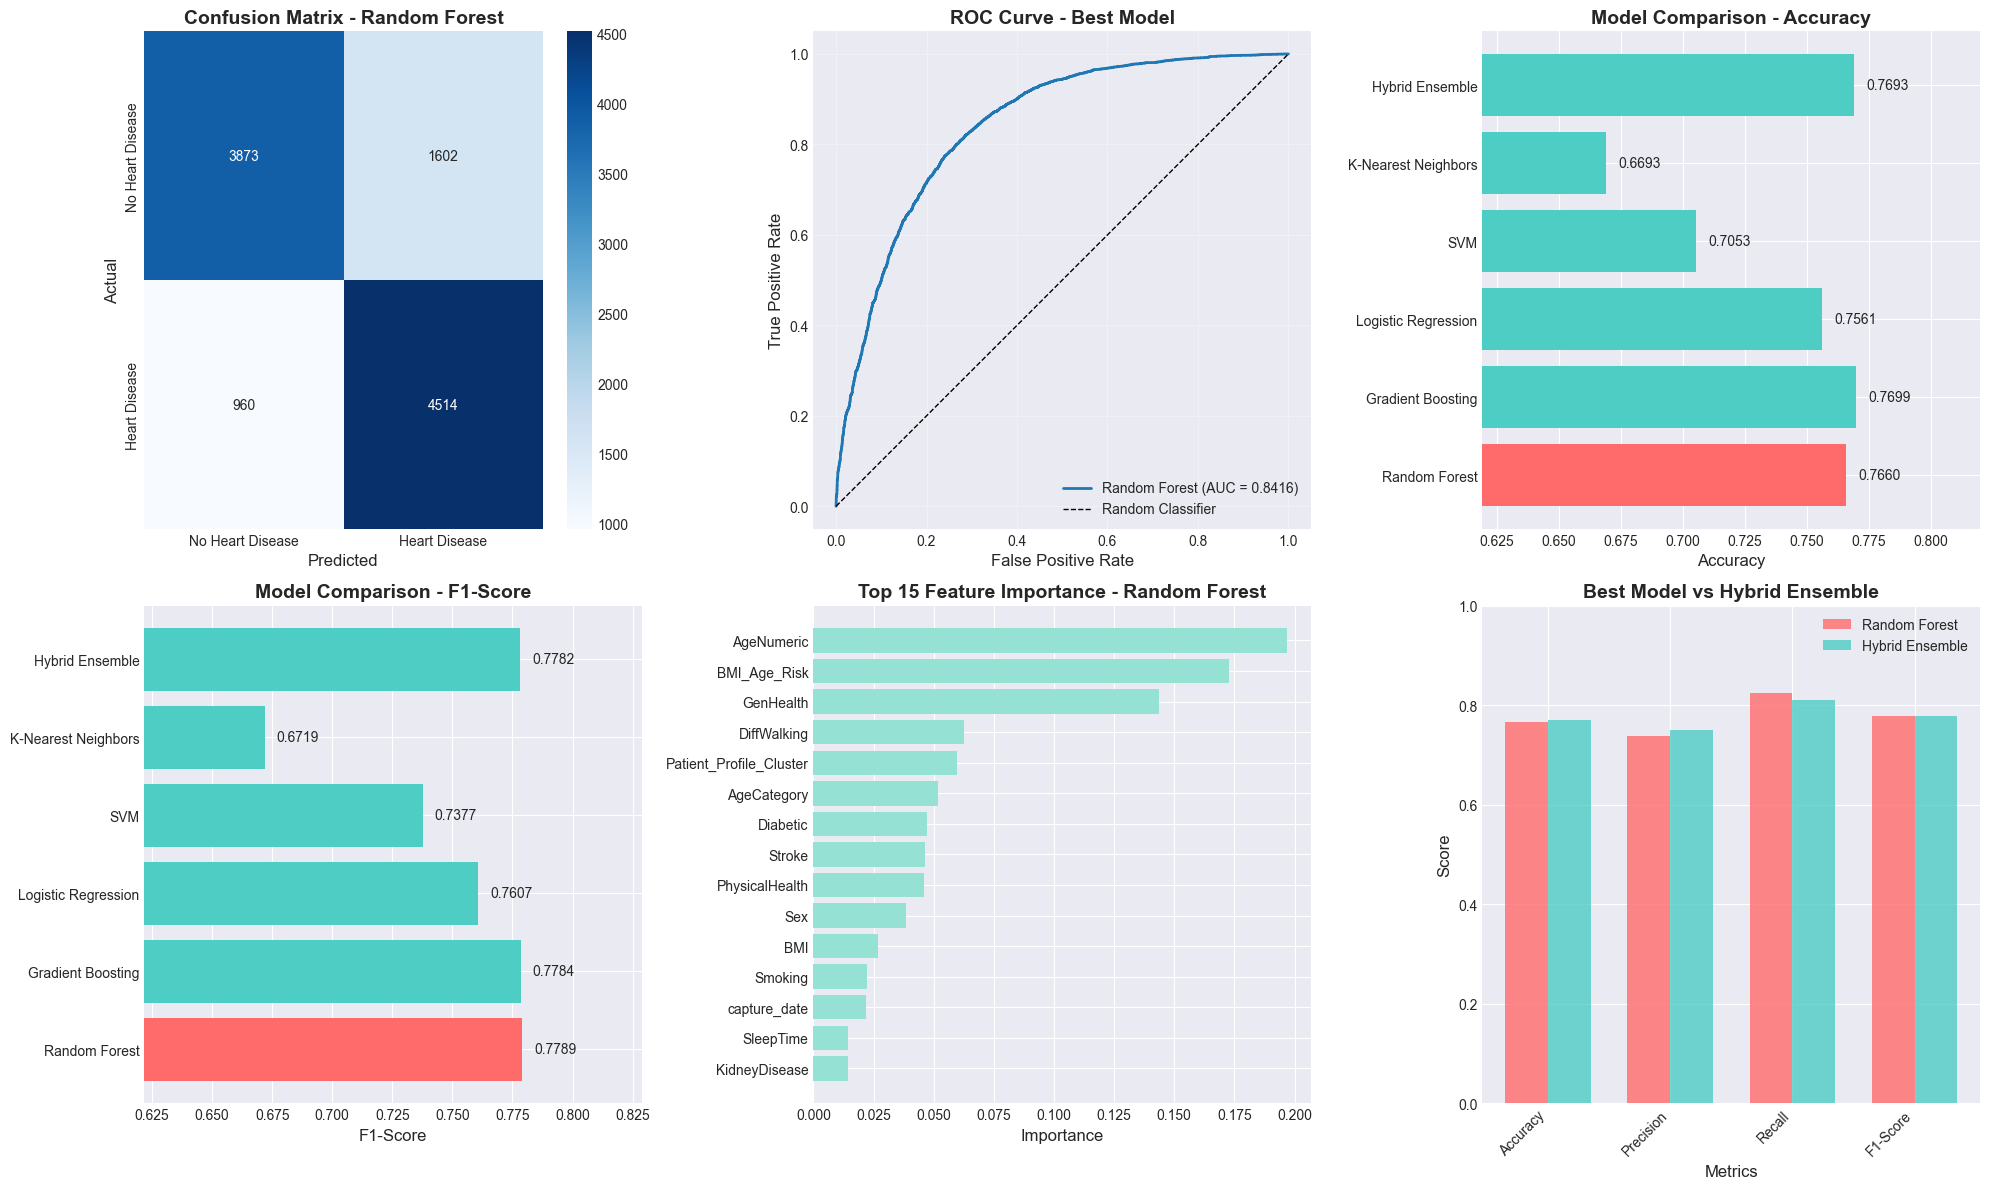


Visualizations completed! Best model: Random Forest


In [ ]:
# Visualization of Model Performance
print("=" * 70)
print("VISUALIZING MODEL PERFORMANCE")
print("=" * 70)

# Set up the plotting style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
fig = plt.figure(figsize=(20, 12))

# 1. Confusion Matrix for Best Model
plt.subplot(2, 3, 1)
cm = confusion_matrix(y_test, results[best_model_name]['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

# 2. ROC Curve for Best Model
plt.subplot(2, 3, 2)
fpr, tpr, _ = roc_curve(y_test, results[best_model_name]['probabilities'])
plt.plot(fpr, tpr, linewidth=2, label=f'{best_model_name} (AUC = {results[best_model_name]["auc"]:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Best Model', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# 3. Model Comparison - Accuracy
plt.subplot(2, 3, 3)
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
colors = ['#FF6B6B' if m == best_model_name else '#4ECDC4' for m in model_names]
plt.barh(model_names, accuracies, color=colors)
plt.xlabel('Accuracy', fontsize=12)
plt.title('Model Comparison - Accuracy', fontsize=14, fontweight='bold')
plt.xlim([min(accuracies) - 0.05, max(accuracies) + 0.05])
for i, v in enumerate(accuracies):
    plt.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

# 4. Model Comparison - F1-Score
plt.subplot(2, 3, 4)
f1_scores = [results[m]['f1'] for m in model_names]
colors = ['#FF6B6B' if m == best_model_name else '#4ECDC4' for m in model_names]
plt.barh(model_names, f1_scores, color=colors)
plt.xlabel('F1-Score', fontsize=12)
plt.title('Model Comparison - F1-Score', fontsize=14, fontweight='bold')
plt.xlim([min(f1_scores) - 0.05, max(f1_scores) + 0.05])
for i, v in enumerate(f1_scores):
    plt.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

# 5. Feature Importance (for tree-based models)
plt.subplot(2, 3, 5)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).head(15)
    
    plt.barh(feature_importance['feature'], feature_importance['importance'], color='#95E1D3')
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'Top 15 Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
else:
    plt.text(0.5, 0.5, 'Feature importance\nnot available\nfor this model', 
             ha='center', va='center', fontsize=12, transform=plt.gca().transAxes)
    plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')

# 6. Metrics Comparison Radar Chart (simplified bar chart)
plt.subplot(2, 3, 6)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
best_metrics = [
    results[best_model_name]['accuracy'],
    results[best_model_name]['precision'],
    results[best_model_name]['recall'],
    results[best_model_name]['f1']
]
hybrid_metrics = [
    results['Hybrid Ensemble']['accuracy'],
    results['Hybrid Ensemble']['precision'],
    results['Hybrid Ensemble']['recall'],
    results['Hybrid Ensemble']['f1']
]

x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, best_metrics, width, label=best_model_name, color='#FF6B6B', alpha=0.8)
plt.bar(x + width/2, hybrid_metrics, width, label='Hybrid Ensemble', color='#4ECDC4', alpha=0.8)
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Best Model vs Hybrid Ensemble', fontsize=14, fontweight='bold')
plt.xticks(x, metrics, rotation=45, ha='right')
plt.legend()
plt.ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"\nVisualizations completed! Best model: {best_model_name}")

In [ ]:
# Save the trained models for future use
import joblib
import os

print("=" * 70)
print("SAVING TRAINED MODELS")
print("=" * 70)

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save best model
best_model_path = f'models/best_model_{best_model_name.replace(" ", "_").lower()}.pkl'
joblib.dump(best_model, best_model_path)
print(f"✓ Best model saved: {best_model_path}")

# Save hybrid ensemble model
hybrid_model_path = 'models/hybrid_ensemble_model.pkl'
joblib.dump(results['Hybrid Ensemble']['model'], hybrid_model_path)
print(f"✓ Hybrid ensemble model saved: {hybrid_model_path}")

# Save all models
all_models_path = 'models/all_models.pkl'
joblib.dump(results, all_models_path)
print(f"✓ All models saved: {all_models_path}")

# Save model comparison results
comparison_df.to_csv('models/model_comparison_results.csv', index=False)
print(f"✓ Model comparison results saved: models/model_comparison_results.csv")

print("\n" + "=" * 70)
print("MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("=" * 70)
print(f"\nSummary:")
print(f"  - Total models trained: {len(results)}")
print(f"  - Best performing model: {best_model_name}")
print(f"  - Best model accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"  - Best model F1-Score: {results[best_model_name]['f1']:.4f}")
print(f"  - Hybrid ensemble accuracy: {results['Hybrid Ensemble']['accuracy']:.4f}")
print(f"  - Hybrid ensemble F1-Score: {results['Hybrid Ensemble']['f1']:.4f}")
print(f"\nAll models are saved in the 'models' directory and ready for deployment!")

SAVING TRAINED MODELS
✓ Best model saved: models/best_model_random_forest.pkl
✓ Hybrid ensemble model saved: models/hybrid_ensemble_model.pkl
✓ All models saved: models/all_models.pkl
✓ Model comparison results saved: models/model_comparison_results.csv

MODEL TRAINING COMPLETED SUCCESSFULLY!

Summary:
  - Total models trained: 6
  - Best performing model: Random Forest
  - Best model accuracy: 0.7660
  - Best model F1-Score: 0.7789
  - Hybrid ensemble accuracy: 0.7693
  - Hybrid ensemble F1-Score: 0.7782

All models are saved in the 'models' directory and ready for deployment!


CONFUSION MATRICES FOR ALL MODELS


C:\Users\Shuchuna\AppData\Local\Temp\ipykernel_24012\3068432896.py:38: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Shuchuna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


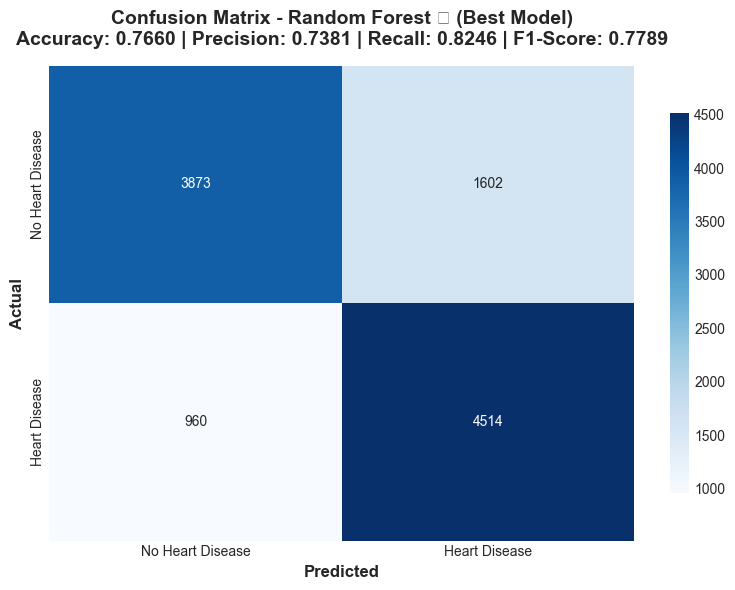

✓ Confusion matrix visualized for: Random Forest


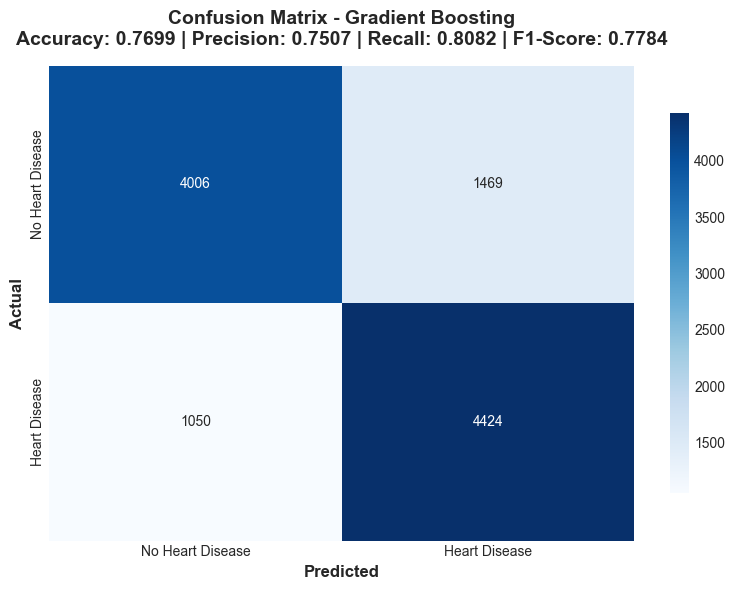

✓ Confusion matrix visualized for: Gradient Boosting


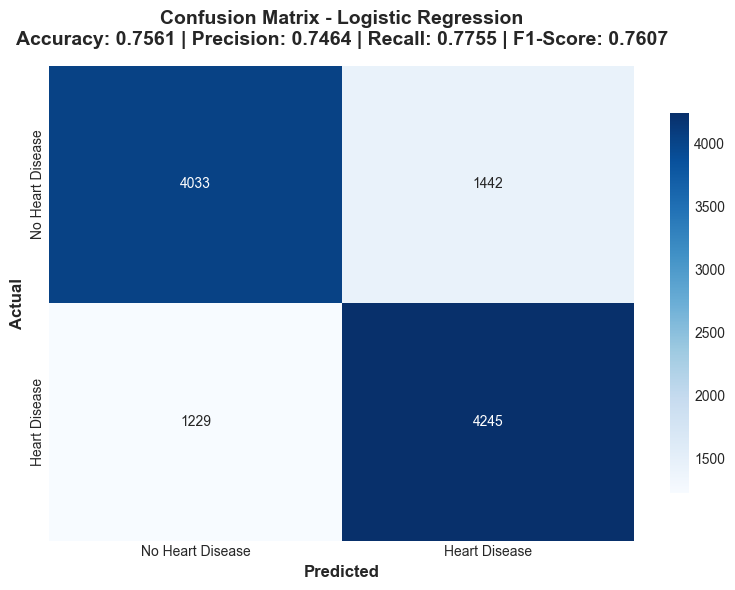

✓ Confusion matrix visualized for: Logistic Regression


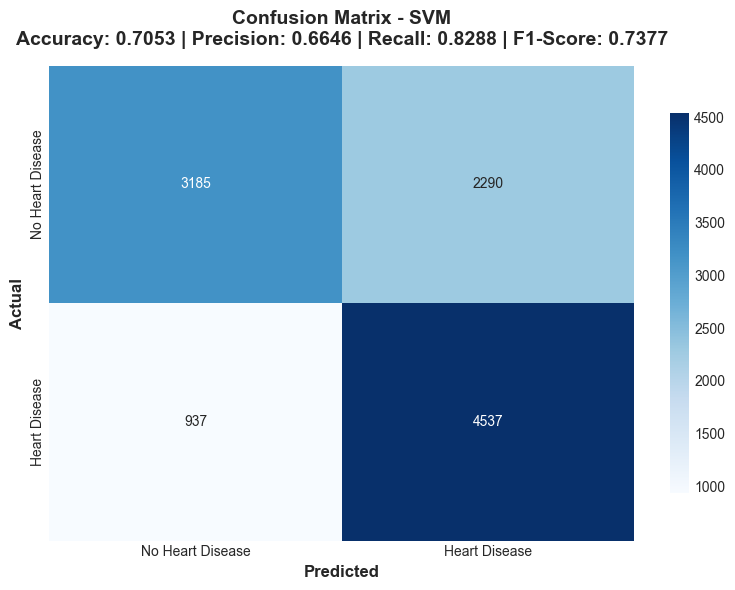

✓ Confusion matrix visualized for: SVM


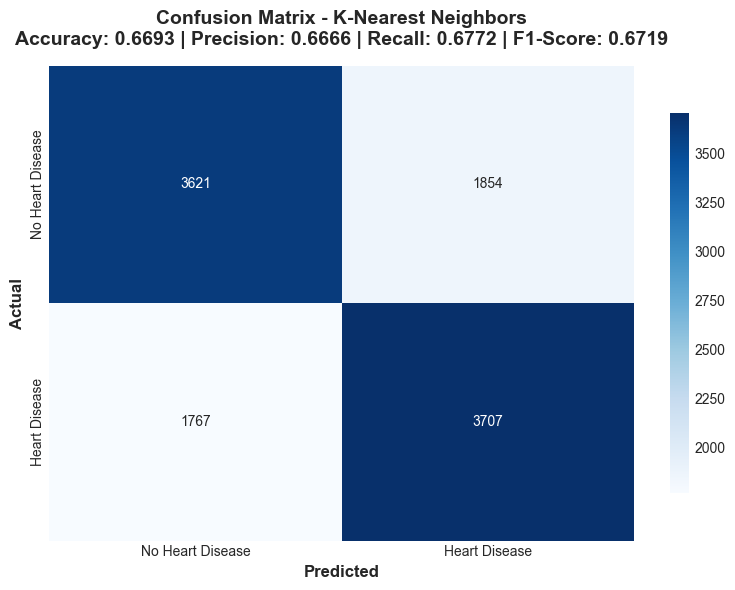

✓ Confusion matrix visualized for: K-Nearest Neighbors


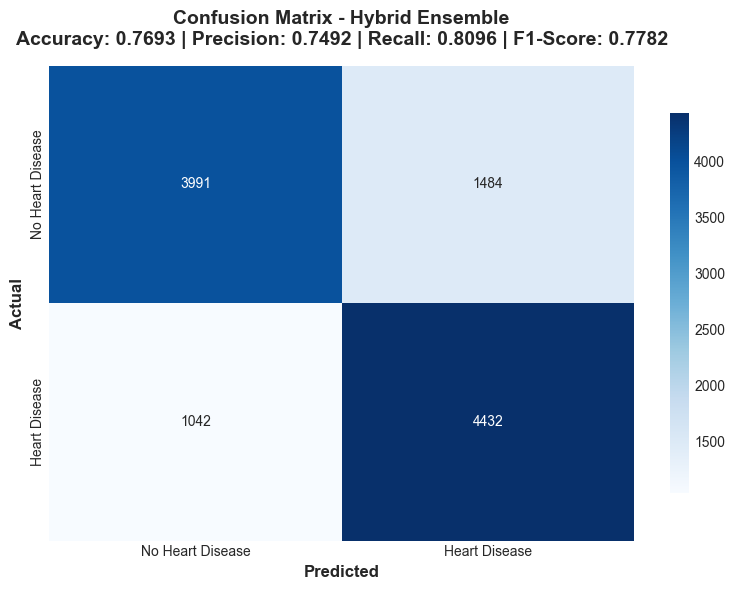

✓ Confusion matrix visualized for: Hybrid Ensemble

✓ All 6 confusion matrices visualized!
⭐ Best model: Random Forest


In [ ]:
# Visualize Confusion Matrices for All 6 Models (Separate Images)
print("=" * 70)
print("CONFUSION MATRICES FOR ALL MODELS")
print("=" * 70)

# Get all model names
model_names = list(results.keys())

# Create a separate figure for each model
for model_name in model_names:
    # Create a new figure for each model
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, results[model_name]['predictions'])
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Heart Disease', 'Heart Disease'],
                yticklabels=['No Heart Disease', 'Heart Disease'],
                cbar_kws={'shrink': 0.8})
    
    # Calculate metrics for display
    accuracy = results[model_name]['accuracy']
    precision = results[model_name]['precision']
    recall = results[model_name]['recall']
    f1 = results[model_name]['f1']
    
    # Set title with metrics
    title = f'Confusion Matrix - {model_name}\nAccuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}'
    if model_name == best_model_name:
        title = f'Confusion Matrix - {model_name} ⭐ (Best Model)\nAccuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}'
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Confusion matrix visualized for: {model_name}")

print(f"\n✓ All {len(model_names)} confusion matrices visualized!")
print(f"⭐ Best model: {best_model_name}")


In [ ]:
import joblib

try:
    # Based on your notebook, it looks like your models are in a dictionary 
    # and you tracked the best one using 'best_model_name'
    best_trained_model = models[best_model_name]
    
    # Now we save it!
    joblib.dump(best_trained_model, 'heart_disease_model.pkl')
    print(f"✅ Successfully saved your best model ({best_model_name}) as 'heart_disease_model.pkl'!")
    
except NameError:
    print("❌ The dictionary name isn't 'models'. Please look at the cell where you used `.fit(X_train, y_train)` and tell me the variable name!")

✅ Successfully saved your best model (Random Forest) as 'heart_disease_model.pkl'!


In [ ]:
# =============================================================================
# PERSONALIZED LIFESTYLE RECOMMENDATION SYSTEM
# =============================================================================

def generate_recommendations(patient_data, model, risk_probability):
    """
    Generate personalized lifestyle recommendations based on patient health conditions
    
    Parameters:
    - patient_data: Dictionary or Series with patient health information
    - model: Trained model for prediction
    - risk_probability: Probability of heart disease risk (0-1)
    
    Returns:
    - Dictionary with categorized recommendations
    """
    recommendations = {
        'diet': [],
        'exercise': [],
        'lifestyle': [],
        'medical': [],
        'sleep': [],
        'stress_management': []
    }
    
    risk_level = 'High' if risk_probability >= 0.7 else 'Moderate' if risk_probability >= 0.4 else 'Low'
    
    # BMI-based recommendations
    bmi = patient_data.get('BMI', 25)
    if bmi >= 30:
        recommendations['diet'].append({
            'priority': 'High',
            'title': 'Weight Management',
            'description': 'Your BMI indicates obesity. Focus on calorie-controlled diet.',
            'actions': [
                'Reduce daily calorie intake by 500-750 calories',
                'Increase vegetable and fruit consumption (5-7 servings/day)',
                'Limit processed foods and sugary beverages',
                'Consider portion control and mindful eating'
            ]
        })
        recommendations['exercise'].append({
            'priority': 'High',
            'title': 'Regular Physical Activity',
            'description': 'Aim for 150-300 minutes of moderate exercise per week.',
            'actions': [
                'Start with 30 minutes of walking daily',
                'Gradually increase to 45-60 minutes',
                'Include strength training 2-3 times/week',
                'Consider low-impact exercises if you have joint issues'
            ]
        })
    elif bmi >= 25:
        recommendations['diet'].append({
            'priority': 'Moderate',
            'title': 'Maintain Healthy Weight',
            'description': 'Your BMI is slightly elevated. Focus on maintaining or reducing weight.',
            'actions': [
                'Monitor portion sizes',
                'Choose whole grains over refined grains',
                'Include lean proteins in meals',
                'Stay hydrated with water'
            ]
        })
    
    # Smoking recommendations
    if patient_data.get('Smoking', 0) == 1:
        recommendations['lifestyle'].append({
            'priority': 'Critical',
            'title': 'Quit Smoking',
            'description': 'Smoking is a major risk factor for heart disease.',
            'actions': [
                'Seek professional help for smoking cessation',
                'Consider nicotine replacement therapy',
                'Join a support group or smoking cessation program',
                'Avoid triggers and create a quit plan',
                'Benefits start within 20 minutes of quitting'
            ]
        })
    
    # Physical Activity recommendations
    physical_activity = patient_data.get('PhysicalActivity', 0)
    if physical_activity == 0:
        recommendations['exercise'].append({
            'priority': 'High',
            'title': 'Start Physical Activity',
            'description': 'Regular exercise significantly reduces heart disease risk.',
            'actions': [
                'Start with 10-15 minutes of daily activity',
                'Gradually increase to 30 minutes, 5 days/week',
                'Choose activities you enjoy (walking, cycling, swimming)',
                'Aim for 150 minutes of moderate-intensity exercise weekly',
                'Include muscle-strengthening activities 2 days/week'
            ]
        })
    elif physical_activity == 1:
        recommendations['exercise'].append({
            'priority': 'Moderate',
            'title': 'Maintain and Enhance Activity',
            'description': 'Great! Keep up your physical activity.',
            'actions': [
                'Aim for 150-300 minutes of moderate activity weekly',
                'Include variety: cardio, strength, flexibility',
                'Consider increasing intensity gradually',
                'Track your activity progress'
            ]
        })
    
    # Sleep recommendations
    sleep_time = patient_data.get('SleepTime', 7)
    if sleep_time < 6:
        recommendations['sleep'].append({
            'priority': 'High',
            'title': 'Improve Sleep Duration',
            'description': 'Inadequate sleep increases heart disease risk.',
            'actions': [
                'Aim for 7-9 hours of sleep per night',
                'Maintain consistent sleep schedule',
                'Create a relaxing bedtime routine',
                'Avoid screens 1 hour before bed',
                'Keep bedroom cool, dark, and quiet'
            ]
        })
    elif sleep_time > 9:
        recommendations['sleep'].append({
            'priority': 'Moderate',
            'title': 'Optimize Sleep Duration',
            'description': 'Excessive sleep may indicate underlying health issues.',
            'actions': [
                'Aim for 7-9 hours of sleep',
                'Evaluate sleep quality',
                'Consider sleep study if excessive sleepiness persists'
            ]
        })
    
    # Mental Health recommendations
    mental_health = patient_data.get('MentalHealth', 0)
    if mental_health > 10:
        recommendations['stress_management'].append({
            'priority': 'High',
            'title': 'Manage Stress and Mental Health',
            'description': 'High stress levels negatively impact heart health.',
            'actions': [
                'Practice relaxation techniques (meditation, deep breathing)',
                'Engage in stress-reducing activities (yoga, hobbies)',
                'Consider counseling or therapy',
                'Maintain social connections',
                'Practice mindfulness and gratitude'
            ]
        })
    
    # Physical Health recommendations
    physical_health = patient_data.get('PhysicalHealth', 0)
    if physical_health > 10:
        recommendations['medical'].append({
            'priority': 'High',
            'title': 'Address Physical Health Issues',
            'description': 'Poor physical health days indicate health concerns.',
            'actions': [
                'Schedule regular health check-ups',
                'Follow medical advice for chronic conditions',
                'Take prescribed medications as directed',
                'Monitor blood pressure and cholesterol regularly'
            ]
        })
    
    # Alcohol recommendations
    if patient_data.get('AlcoholDrinking', 0) == 1:
        recommendations['lifestyle'].append({
            'priority': 'Moderate',
            'title': 'Moderate Alcohol Consumption',
            'description': 'Excessive alcohol increases heart disease risk.',
            'actions': [
                'Limit to 1 drink per day for women, 2 for men',
                'Avoid binge drinking',
                'Consider alcohol-free days',
                'Choose red wine in moderation if drinking'
            ]
        })
    
    # Diabetic recommendations
    diabetic = patient_data.get('Diabetic', 0)
    if diabetic in [1, 2, 3]:  # Assuming encoded values for different diabetic states
        recommendations['diet'].append({
            'priority': 'Critical',
            'title': 'Diabetes Management',
            'description': 'Diabetes significantly increases heart disease risk.',
            'actions': [
                'Monitor blood glucose levels regularly',
                'Follow diabetic meal plan (low glycemic index foods)',
                'Take medications as prescribed',
                'Maintain regular A1C checks',
                'Work with diabetes educator'
            ]
        })
    
    # General Health recommendations based on GenHealth
    gen_health = patient_data.get('GenHealth', 2)  # Assuming 0=Poor, 4=Excellent
    if gen_health <= 1:
        recommendations['diet'].append({
            'priority': 'High',
            'title': 'Improve Overall Diet Quality',
            'description': 'Focus on heart-healthy eating patterns.',
            'actions': [
                'Follow DASH or Mediterranean diet',
                'Reduce sodium intake (<2300mg/day)',
                'Increase omega-3 fatty acids (fish, nuts)',
                'Limit saturated and trans fats',
                'Eat more fiber-rich foods'
            ]
        })
    
    # Age-based recommendations
    age = patient_data.get('AgeNumeric', 50)
    if age >= 65:
        recommendations['medical'].append({
            'priority': 'Moderate',
            'title': 'Regular Health Monitoring',
            'description': 'Older adults need regular cardiovascular monitoring.',
            'actions': [
                'Annual cardiovascular risk assessment',
                'Regular blood pressure monitoring',
                'Cholesterol screening every 4-6 years',
                'Discuss aspirin therapy with doctor'
            ]
        })
    
    # Risk-based general recommendations
    if risk_level == 'High':
        recommendations['medical'].append({
            'priority': 'Critical',
            'title': 'Immediate Medical Consultation',
            'description': 'You have a high risk of heart disease. Consult a cardiologist.',
            'actions': [
                'Schedule appointment with cardiologist',
                'Complete comprehensive cardiac evaluation',
                'Discuss preventive medications',
                'Create personalized risk reduction plan'
            ]
        })
    
    return recommendations, risk_level

print("Recommendation system function created successfully!")

Recommendation system function created successfully!


In [ ]:
# Function to process patient data and create recommendation charts
def create_patient_recommendation_chart(patient_idx=None, patient_data=None, model=None):
    """
    Create personalized recommendation chart for a patient
    
    Parameters:
    - patient_idx: Index of patient in test set (optional)
    - patient_data: Direct patient data dictionary (optional)
    - model: Trained model to use for prediction
    """
    if model is None:
        model = best_model
    
    # Get patient data
    if patient_data is None:
        if patient_idx is None:
            # Use a random patient from test set
            patient_idx = np.random.randint(0, len(X_test))
        patient_features = X_test.iloc[patient_idx]
        patient_data_dict = patient_features.to_dict()
    else:
        patient_data_dict = patient_data.copy()
    
    # Get prediction
    if patient_data is None:
        patient_array = X_test.iloc[patient_idx:patient_idx+1]
    else:
        # Convert dict to array format matching training data
        patient_array = pd.DataFrame([patient_data_dict])
        # Ensure columns match
        for col in X_train.columns:
            if col not in patient_array.columns:
                patient_array[col] = 0
    
    risk_probability = model.predict_proba(patient_array)[0][1]
    prediction = model.predict(patient_array)[0]
    
    # Generate recommendations
    recommendations, risk_level = generate_recommendations(patient_data_dict, model, risk_probability)
    
    # Create visualization
    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(f'Personalized Heart Disease Prevention Recommendations\n'
                 f'Risk Level: {risk_level.upper()} | Risk Probability: {risk_probability:.2%} | '
                 f'Prediction: {"Heart Disease Risk" if prediction == 1 else "Low Risk"}',
                 fontsize=16, fontweight='bold', y=0.98)
    
    # Color scheme based on risk
    risk_colors = {'High': '#FF6B6B', 'Moderate': '#FFA500', 'Low': '#4ECDC4'}
    priority_colors = {'Critical': '#DC143C', 'High': '#FF6B6B', 'Moderate': '#FFA500', 'Low': '#95E1D3'}
    
    # Plot 1: Risk Assessment Gauge
    ax1 = plt.subplot(3, 3, 1)
    categories = ['Diet', 'Exercise', 'Lifestyle', 'Medical', 'Sleep', 'Stress']
    rec_counts = [len(recommendations[cat]) for cat in ['diet', 'exercise', 'lifestyle', 'medical', 'sleep', 'stress_management']]
    
    colors_list = [risk_colors[risk_level] if count > 0 else '#E0E0E0' for count in rec_counts]
    bars = ax1.barh(categories, rec_counts, color=colors_list)
    ax1.set_xlabel('Number of Recommendations', fontsize=11)
    ax1.set_title('Recommendations by Category', fontsize=12, fontweight='bold')
    ax1.set_xlim(0, max(rec_counts) + 1 if max(rec_counts) > 0 else 1)
    for i, (bar, count) in enumerate(zip(bars, rec_counts)):
        if count > 0:
            ax1.text(count + 0.1, i, str(count), va='center', fontsize=10, fontweight='bold')
    
    # Plot 2: Risk Probability Gauge
    ax2 = plt.subplot(3, 3, 2, projection='polar')
    theta = np.linspace(0, 2*np.pi, 100)
    r = np.ones_like(theta)
    ax2.plot(theta, r, 'k-', linewidth=2)
    risk_angle = risk_probability * 2 * np.pi
    ax2.fill_between(theta[:int(risk_probability*100)], 0, 1, color=risk_colors[risk_level], alpha=0.6)
    ax2.plot([0, risk_angle], [0, 1], 'k-', linewidth=3)
    ax2.set_ylim(0, 1.2)
    ax2.set_title(f'Heart Disease Risk: {risk_probability:.1%}', fontsize=12, fontweight='bold', pad=20)
    ax2.set_xticks([])
    ax2.set_yticks([])
    
    # Plot 3-8: Detailed recommendations by category
    plot_positions = [(3, 3, 3), (3, 3, 4), (3, 3, 5), (3, 3, 6), (3, 3, 7), (3, 3, 8)]
    category_names = ['Diet & Nutrition', 'Exercise & Activity', 'Lifestyle Changes', 
                      'Medical Care', 'Sleep Health', 'Stress Management']
    category_keys = ['diet', 'exercise', 'lifestyle', 'medical', 'sleep', 'stress_management']
    
    for pos, cat_name, cat_key in zip(plot_positions, category_names, category_keys):
        ax = plt.subplot(*pos)
        if len(recommendations[cat_key]) > 0:
            # Create text box with recommendations
            text_content = f"\\n{cat_name}\\n{'='*30}\\n\\n"
            for i, rec in enumerate(recommendations[cat_key][:3], 1):  # Show top 3
                text_content += f"\\n{i}. {rec['title']} ({rec['priority']})\\n"
                text_content += f"   {rec['description']}\\n"
                if len(rec['actions']) > 0:
                    text_content += f"   • {rec['actions'][0]}\\n"
            ax.text(0.05, 0.95, text_content, transform=ax.transAxes, 
                   fontsize=9, verticalalignment='top', family='monospace',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
        else:
            ax.text(0.5, 0.5, f'No specific\\nrecommendations\\nfor {cat_name}', 
                   ha='center', va='center', fontsize=11, 
                   bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
    
    # Plot 9: Priority Action Items
    ax9 = plt.subplot(3, 3, 9)
    priority_items = []
    for cat_key, cat_recs in recommendations.items():
        for rec in cat_recs:
            if rec['priority'] in ['Critical', 'High']:
                priority_items.append({
                    'title': rec['title'],
                    'category': cat_key.replace('_', ' ').title(),
                    'priority': rec['priority'],
                    'action': rec['actions'][0] if rec['actions'] else 'See details'
                })
    
    if priority_items:
        y_pos = np.arange(len(priority_items))
        priorities = [item['priority'] for item in priority_items]
        colors = [priority_colors[p] for p in priorities]
        
        ax9.barh(y_pos, [1]*len(priority_items), color=colors, alpha=0.7)
        ax9.set_yticks(y_pos)
        ax9.set_yticklabels([f"{item['title']}" for item in priority_items], fontsize=9)
        ax9.set_xlim(0, 1)
        ax9.set_xlabel('Priority Level', fontsize=10)
        ax9.set_title('Top Priority Actions', fontsize=12, fontweight='bold')
        ax9.set_xticks([])
    else:
        ax9.text(0.5, 0.5, 'No high priority\\nactions identified', 
                ha='center', va='center', fontsize=11)
        ax9.set_xticks([])
        ax9.set_yticks([])
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    # Print detailed recommendations
    print("\\n" + "="*70)
    print("DETAILED RECOMMENDATIONS")
    print("="*70)
    for cat_key, cat_name in zip(category_keys, category_names):
        if len(recommendations[cat_key]) > 0:
            print(f"\\n{cat_name.upper()}:")
            print("-" * 70)
            for rec in recommendations[cat_key]:
                print(f"\\n[{rec['priority']}] {rec['title']}")
                print(f"  {rec['description']}")
                print("  Actions:")
                for action in rec['actions']:
                    print(f"    • {action}")
    
    return recommendations, risk_level, risk_probability

print("Patient recommendation chart function created successfully!")

Patient recommendation chart function created successfully!


GENERATING PERSONALIZED RECOMMENDATIONS FOR SAMPLE PATIENTS
\nGenerating recommendations for 3 sample patients...
\n======================================================================
PATIENT 1 - Index 1
\nPatient Health Profile:
  - Risk Probability: 81.83%
  - Prediction: Heart Disease Risk
\nKey Health Metrics:
  - BMI: 27.41
  - SleepTime: 7.00
  - PhysicalHealth: 0.00
  - MentalHealth: 0.00
  - PhysicalActivity: Yes
  - Smoking: No
  - AlcoholDrinking: No


C:\Users\Shuchuna\AppData\Local\Temp\ipykernel_24012\1610864911.py:140: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


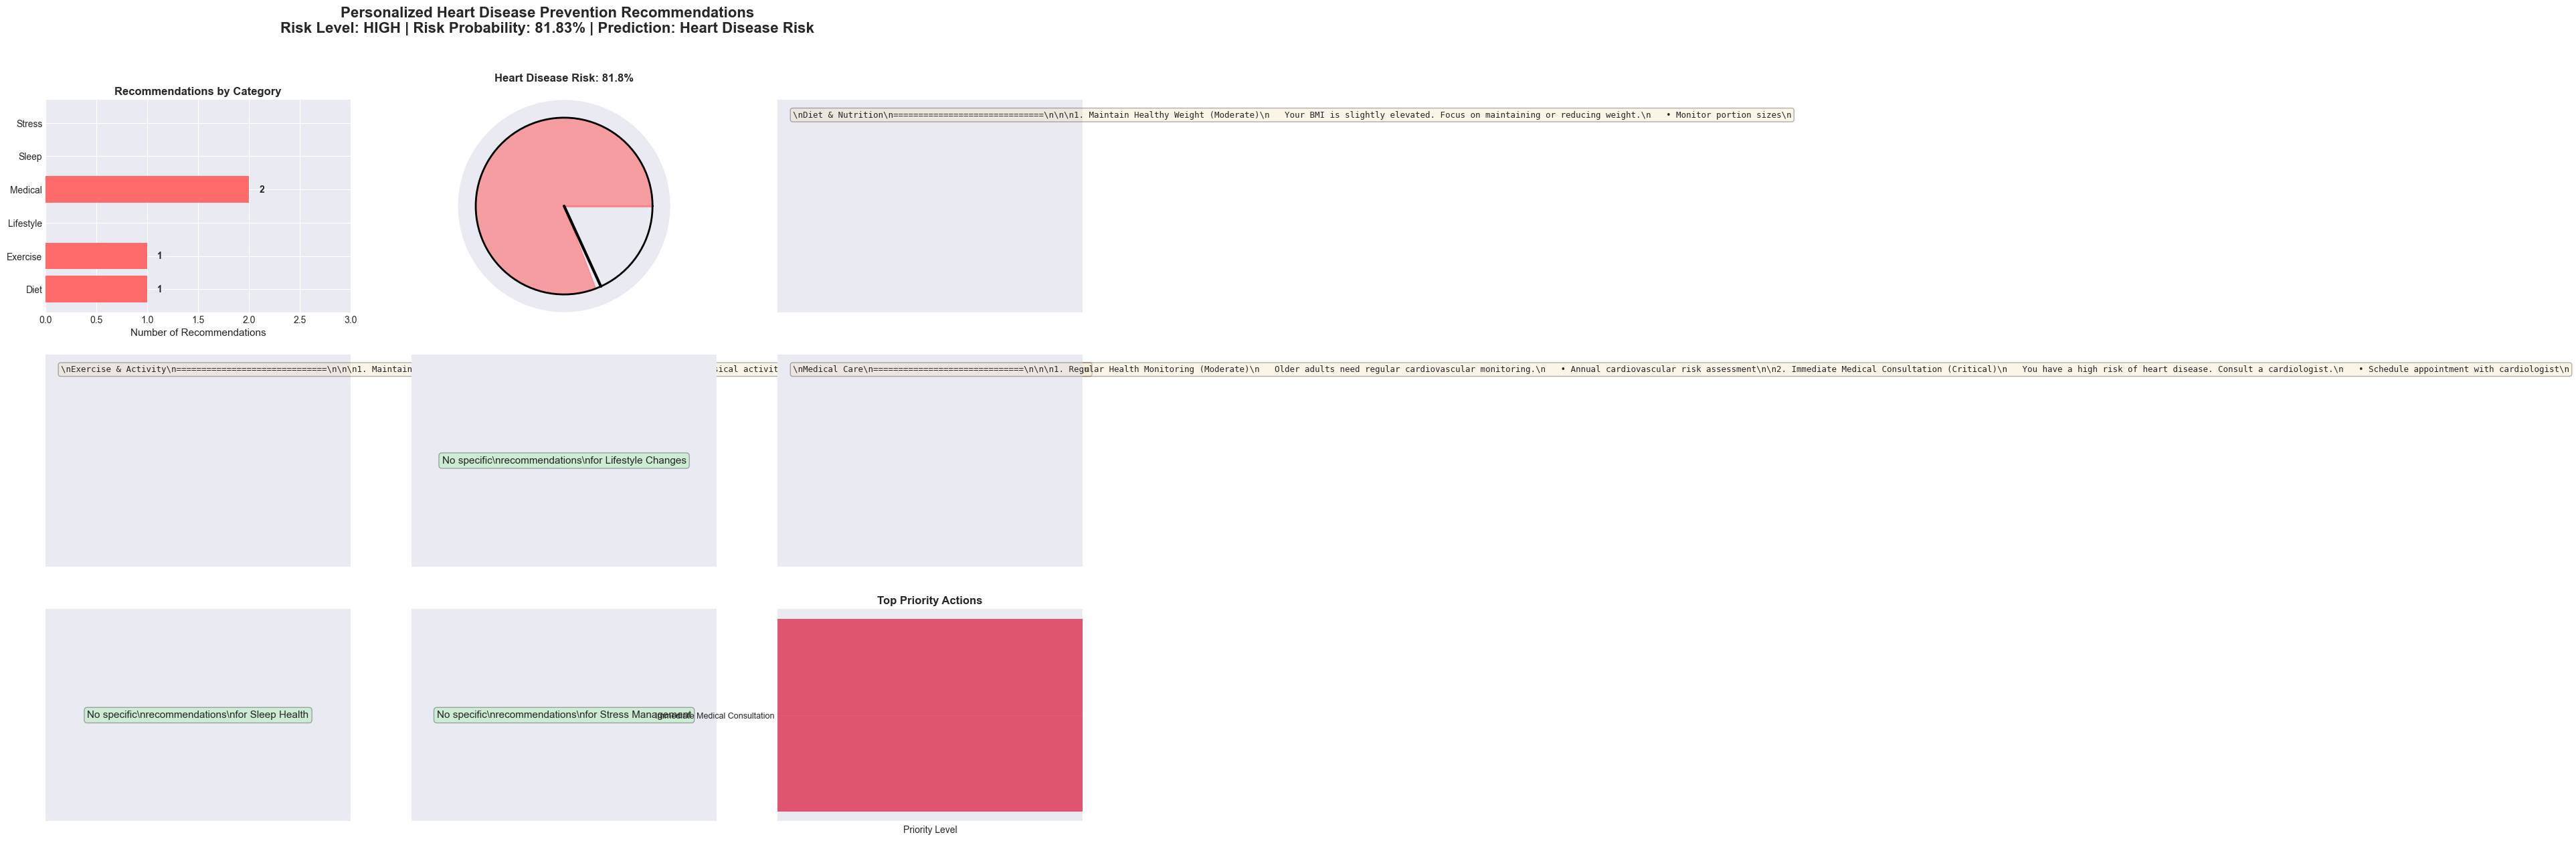

\n======================================================================
DETAILED RECOMMENDATIONS
\nDIET & NUTRITION:
----------------------------------------------------------------------
\n[Moderate] Maintain Healthy Weight
  Your BMI is slightly elevated. Focus on maintaining or reducing weight.
  Actions:
    • Monitor portion sizes
    • Choose whole grains over refined grains
    • Include lean proteins in meals
    • Stay hydrated with water
\nEXERCISE & ACTIVITY:
----------------------------------------------------------------------
\n[Moderate] Maintain and Enhance Activity
  Great! Keep up your physical activity.
  Actions:
    • Aim for 150-300 minutes of moderate activity weekly
    • Include variety: cardio, strength, flexibility
    • Consider increasing intensity gradually
    • Track your activity progress
\nMEDICAL CARE:
----------------------------------------------------------------------
\n[Moderate] Regular Health Monitoring
  Older adults need regular cardiovascul

C:\Users\Shuchuna\AppData\Local\Temp\ipykernel_24012\1610864911.py:140: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


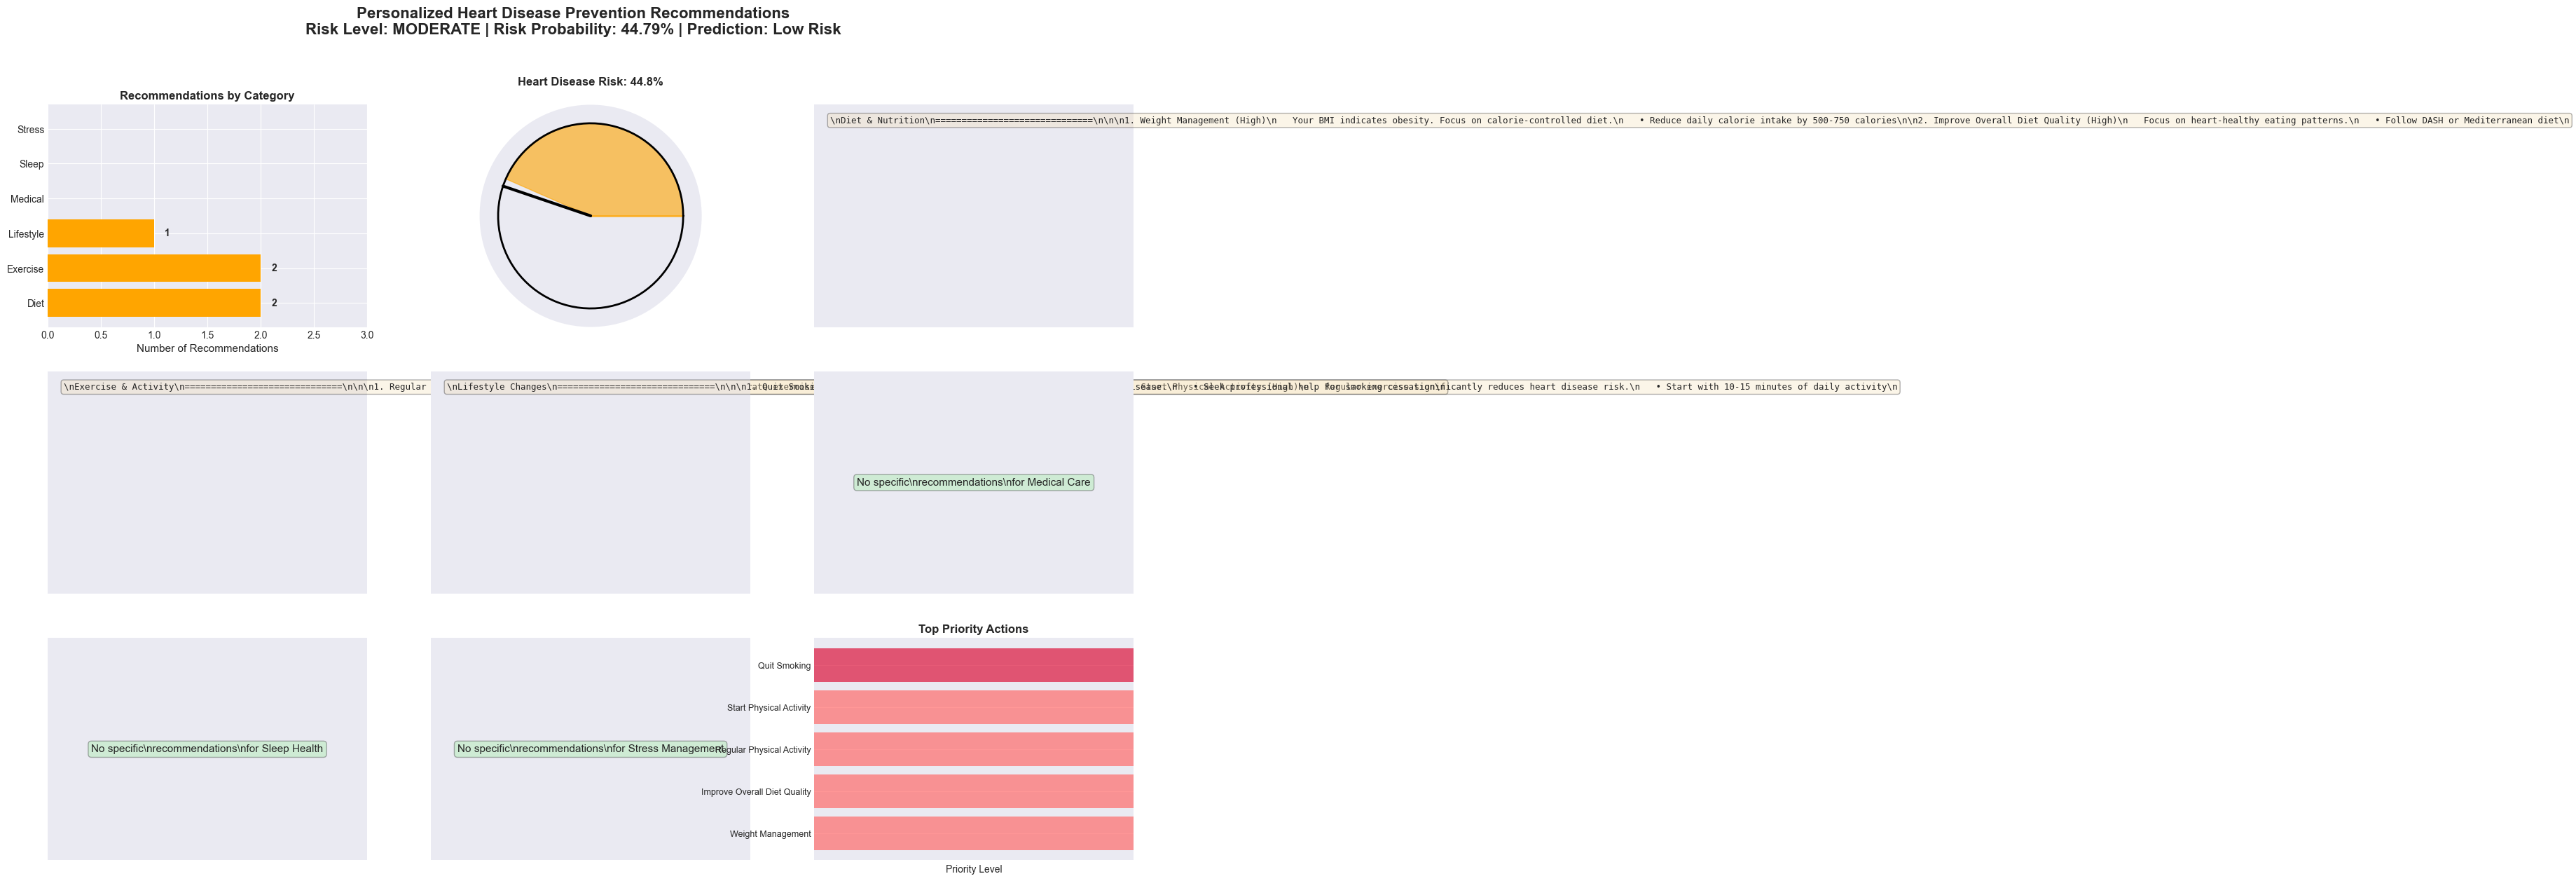

\n======================================================================
DETAILED RECOMMENDATIONS
\nDIET & NUTRITION:
----------------------------------------------------------------------
\n[High] Weight Management
  Your BMI indicates obesity. Focus on calorie-controlled diet.
  Actions:
    • Reduce daily calorie intake by 500-750 calories
    • Increase vegetable and fruit consumption (5-7 servings/day)
    • Limit processed foods and sugary beverages
    • Consider portion control and mindful eating
\n[High] Improve Overall Diet Quality
  Focus on heart-healthy eating patterns.
  Actions:
    • Follow DASH or Mediterranean diet
    • Reduce sodium intake (<2300mg/day)
    • Increase omega-3 fatty acids (fish, nuts)
    • Limit saturated and trans fats
    • Eat more fiber-rich foods
\nEXERCISE & ACTIVITY:
----------------------------------------------------------------------
\n[High] Regular Physical Activity
  Aim for 150-300 minutes of moderate exercise per week.
  Actions:
    

C:\Users\Shuchuna\AppData\Local\Temp\ipykernel_24012\1610864911.py:140: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


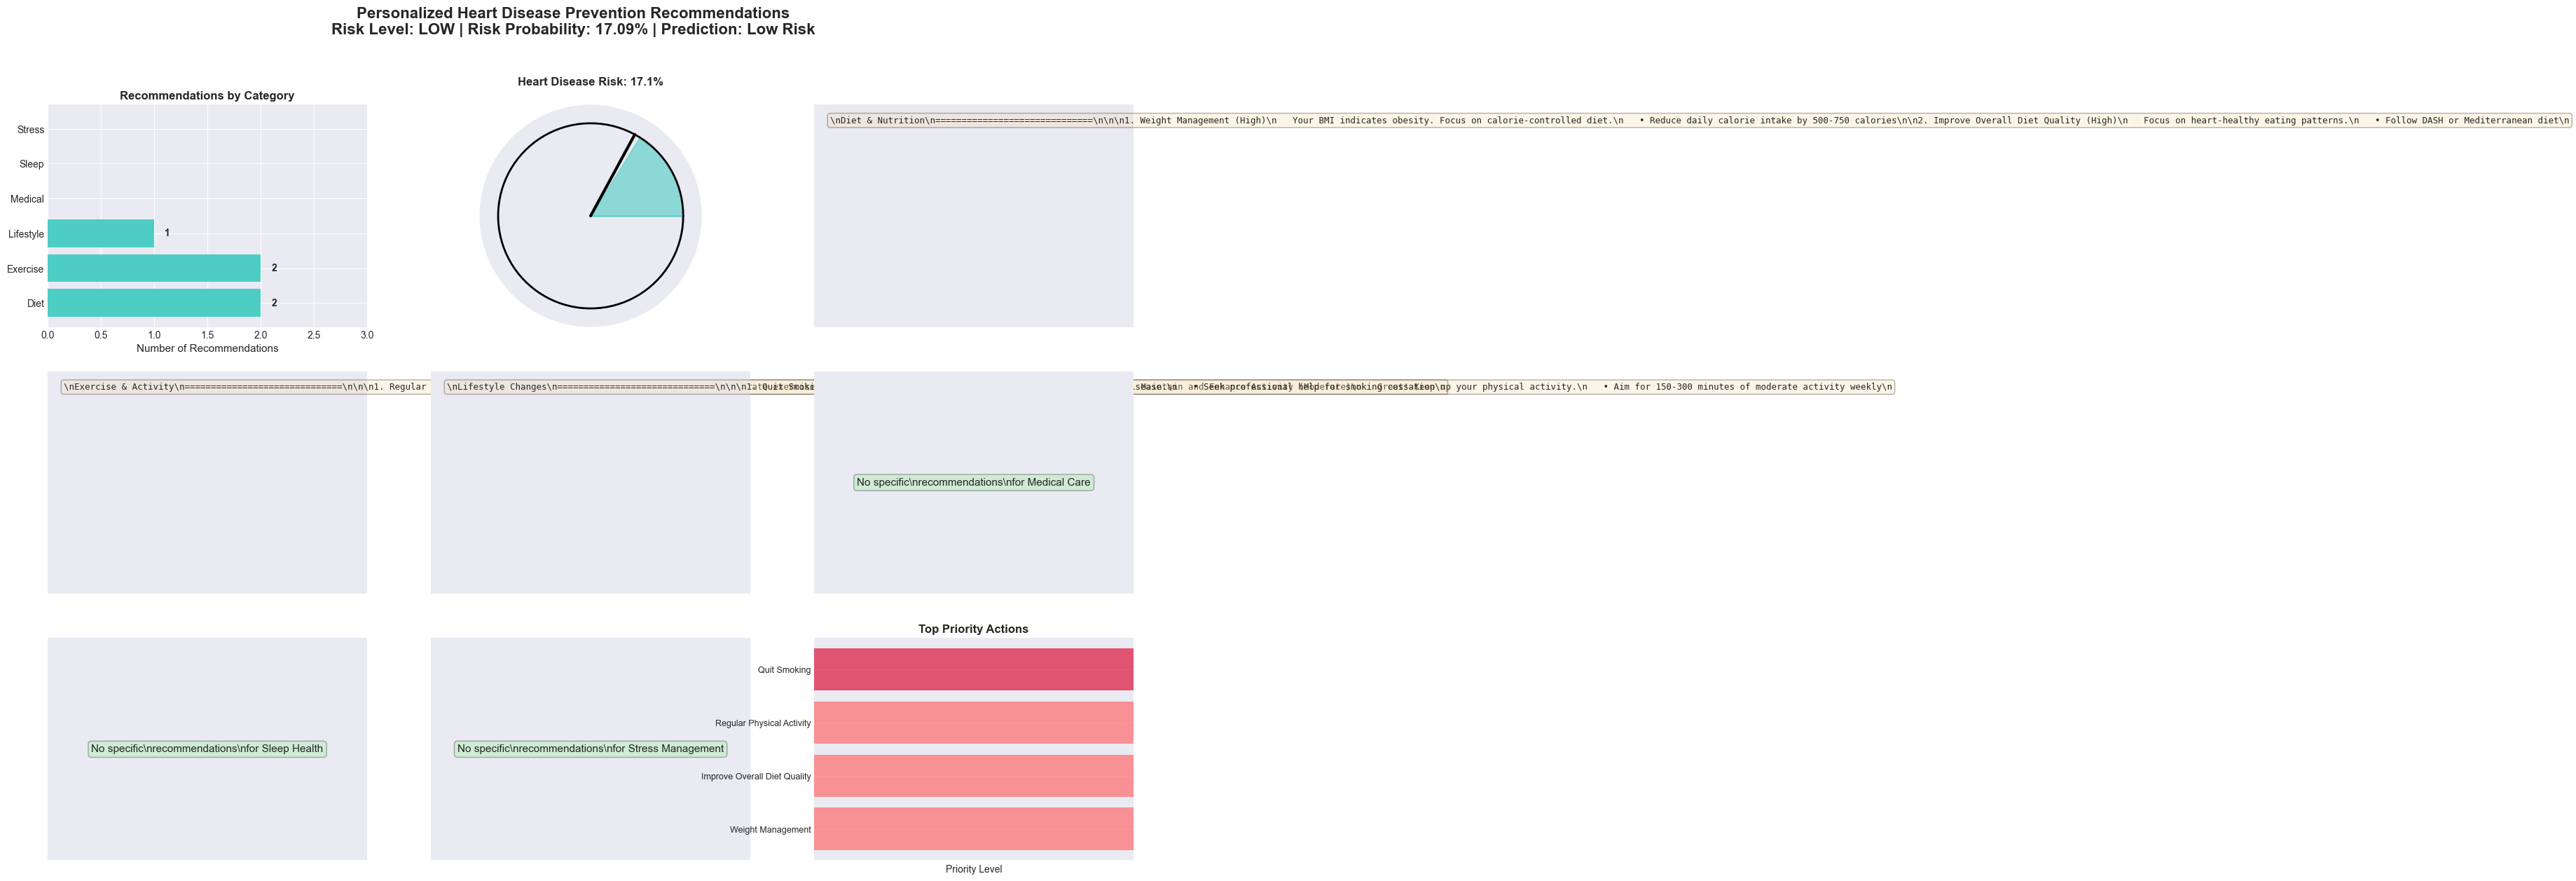

\n======================================================================
DETAILED RECOMMENDATIONS
\nDIET & NUTRITION:
----------------------------------------------------------------------
\n[High] Weight Management
  Your BMI indicates obesity. Focus on calorie-controlled diet.
  Actions:
    • Reduce daily calorie intake by 500-750 calories
    • Increase vegetable and fruit consumption (5-7 servings/day)
    • Limit processed foods and sugary beverages
    • Consider portion control and mindful eating
\n[High] Improve Overall Diet Quality
  Focus on heart-healthy eating patterns.
  Actions:
    • Follow DASH or Mediterranean diet
    • Reduce sodium intake (<2300mg/day)
    • Increase omega-3 fatty acids (fish, nuts)
    • Limit saturated and trans fats
    • Eat more fiber-rich foods
\nEXERCISE & ACTIVITY:
----------------------------------------------------------------------
\n[High] Regular Physical Activity
  Aim for 150-300 minutes of moderate exercise per week.
  Actions:
    

In [ ]:
# =============================================================================
# DEMONSTRATE RECOMMENDATION SYSTEM
# =============================================================================

print("=" * 70)
print("GENERATING PERSONALIZED RECOMMENDATIONS FOR SAMPLE PATIENTS")
print("=" * 70)

# Generate recommendations for 3 sample patients with different risk levels
sample_indices = []

# Find patients with different risk levels
risk_probs = best_model.predict_proba(X_test)[:, 1]
high_risk_idx = np.where(risk_probs >= 0.7)[0]
moderate_risk_idx = np.where((risk_probs >= 0.4) & (risk_probs < 0.7))[0]
low_risk_idx = np.where(risk_probs < 0.4)[0]

if len(high_risk_idx) > 0:
    sample_indices.append(high_risk_idx[0])
if len(moderate_risk_idx) > 0:
    sample_indices.append(moderate_risk_idx[0])
if len(low_risk_idx) > 0:
    sample_indices.append(low_risk_idx[0])

# If we don't have all risk levels, just pick 3 random patients
if len(sample_indices) < 3:
    sample_indices = np.random.choice(len(X_test), 3, replace=False)

print(f"\\nGenerating recommendations for {len(sample_indices)} sample patients...")
print("=" * 70)

# Generate and display recommendations for each sample patient
for i, patient_idx in enumerate(sample_indices[:3], 1):
    print(f"\\n{'='*70}")
    print(f"PATIENT {i} - Index {patient_idx}")
    print(f"{'='*70}")
    
    # Get patient data
    patient_data = X_test.iloc[patient_idx]
    risk_prob = best_model.predict_proba(X_test.iloc[patient_idx:patient_idx+1])[0][1]
    prediction = best_model.predict(X_test.iloc[patient_idx:patient_idx+1])[0]
    
    print(f"\\nPatient Health Profile:")
    print(f"  - Risk Probability: {risk_prob:.2%}")
    print(f"  - Prediction: {'Heart Disease Risk' if prediction == 1 else 'Low Risk'}")
    
    # Display key health metrics if available
    key_features = ['BMI', 'SleepTime', 'PhysicalHealth', 'MentalHealth', 'PhysicalActivity', 
                    'Smoking', 'AlcoholDrinking']
    available_features = [f for f in key_features if f in patient_data.index]
    
    if available_features:
        print(f"\\nKey Health Metrics:")
        for feature in available_features:
            value = patient_data[feature]
            if feature in ['Smoking', 'AlcoholDrinking', 'PhysicalActivity']:
                value_str = 'Yes' if value == 1 else 'No'
            else:
                value_str = f"{value:.2f}" if isinstance(value, (int, float)) else str(value)
            print(f"  - {feature}: {value_str}")
    
    # Generate recommendations
    recommendations, risk_level, _ = create_patient_recommendation_chart(patient_idx=patient_idx, model=best_model)
    
    print(f"\\n{'='*70}\\n")

print("\\n" + "=" * 70)
print("RECOMMENDATION SYSTEM DEMONSTRATION COMPLETED")
print("=" * 70)

In [ ]:
# =============================================================================
# UTILITY FUNCTION: Generate Recommendations for Custom Patient Data
# =============================================================================

def get_recommendations_for_custom_patient(custom_data, model=None):
    """
    Generate recommendations for a custom patient with user-provided data
    
    Parameters:
    - custom_data: Dictionary with patient health information
                  Required keys: BMI, SleepTime, PhysicalHealth, MentalHealth, etc.
    - model: Trained model (defaults to best_model)
    
    Example usage:
    custom_patient = {
        'BMI': 32.5,
        'Smoking': 1,  # 1 = Yes, 0 = No
        'AlcoholDrinking': 0,
        'PhysicalActivity': 0,
        'SleepTime': 5.5,
        'PhysicalHealth': 15,
        'MentalHealth': 12,
        'AgeNumeric': 55,
        'GenHealth': 1,  # 0=Poor, 1=Fair, 2=Good, 3=Very good, 4=Excellent
        'Diabetic': 0
    }
    get_recommendations_for_custom_patient(custom_patient)
    """
    if model is None:
        model = best_model
    
    # Create a DataFrame with the custom data, matching training columns
    patient_df = pd.DataFrame([custom_data])
    
    # Ensure all required columns exist (fill missing with defaults)
    for col in X_train.columns:
        if col not in patient_df.columns:
            # Use median/default values
            if col in X_train.columns:
                patient_df[col] = X_train[col].median() if X_train[col].dtype in ['int64', 'float64'] else 0
            else:
                patient_df[col] = 0
    
    # Reorder columns to match training data
    patient_df = patient_df[X_train.columns]
    
    # Get prediction
    risk_probability = model.predict_proba(patient_df)[0][1]
    prediction = model.predict(patient_df)[0]
    
    # Generate recommendations
    recommendations, risk_level, _ = create_patient_recommendation_chart(
        patient_data=custom_data, 
        model=model
    )
    
    return recommendations, risk_level, risk_probability, prediction

print("\\n" + "=" * 70)
print("CUSTOM PATIENT RECOMMENDATION FUNCTION READY")
print("=" * 70)
print("\\nTo use this function, provide a dictionary with patient data:")
print("\\nExample:")
print("custom_patient = {")
print("    'BMI': 28.5,")
print("    'Smoking': 1,  # 1 = Yes, 0 = No")
print("    'AlcoholDrinking': 0,")
print("    'PhysicalActivity': 0,")
print("    'SleepTime': 6.5,")
print("    'PhysicalHealth': 10,")
print("    'MentalHealth': 8,")
print("    'AgeNumeric': 45,")
print("    'GenHealth': 2,  # 0=Poor, 1=Fair, 2=Good, 3=Very good, 4=Excellent")
print("    'Diabetic': 0")
print("}")
print("\\nget_recommendations_for_custom_patient(custom_patient)")
print("=" * 70)

\n======================================================================
CUSTOM PATIENT RECOMMENDATION FUNCTION READY
\nTo use this function, provide a dictionary with patient data:
\nExample:
custom_patient = {
    'BMI': 28.5,
    'Smoking': 1,  # 1 = Yes, 0 = No
    'AlcoholDrinking': 0,
    'PhysicalActivity': 0,
    'SleepTime': 6.5,
    'PhysicalHealth': 10,
    'MentalHealth': 8,
    'AgeNumeric': 45,
    'GenHealth': 2,  # 0=Poor, 1=Fair, 2=Good, 3=Very good, 4=Excellent
    'Diabetic': 0
}
\nget_recommendations_for_custom_patient(custom_patient)


# Personalized Lifestyle Recommendation System

## Overview
This recommendation system provides personalized daily lifestyle recommendations to prevent heart disease risk based on each patient's health conditions.

## Features

### 1. **Comprehensive Health Analysis**
- Analyzes multiple health factors: BMI, smoking, physical activity, sleep, mental health, etc.
- Calculates heart disease risk probability using trained hybrid model
- Categorizes risk level: Low, Moderate, or High

### 2. **Personalized Recommendations**
Recommendations are provided in 6 categories:
- **Diet & Nutrition**: Weight management, heart-healthy eating patterns
- **Exercise & Activity**: Physical activity guidelines based on current activity level
- **Lifestyle Changes**: Smoking cessation, alcohol moderation
- **Medical Care**: Regular check-ups, medication adherence
- **Sleep Health**: Sleep duration and quality optimization
- **Stress Management**: Mental health and stress reduction techniques

### 3. **Priority-Based Actions**
- **Critical**: Immediate actions required (e.g., quit smoking, medical consultation)
- **High**: Important lifestyle changes
- **Moderate**: Beneficial improvements
- **Low**: Maintenance recommendations

### 4. **Visual Charts**
- Risk probability gauge
- Recommendations by category
- Priority action items
- Detailed recommendations for each category

## Usage

### For Test Set Patients:
```python
# Generate recommendations for a specific patient
create_patient_recommendation_chart(patient_idx=0)

# Or for a random patient
create_patient_recommendation_chart()
```

### For Custom Patient Data:
```python
custom_patient = {
    'BMI': 28.5,
    'Smoking': 1,  # 1 = Yes, 0 = No
    'AlcoholDrinking': 0,
    'PhysicalActivity': 0,
    'SleepTime': 6.5,
    'PhysicalHealth': 10,
    'MentalHealth': 8,
    'AgeNumeric': 45,
    'GenHealth': 2,  # 0=Poor, 1=Fair, 2=Good, 3=Very good, 4=Excellent
    'Diabetic': 0
}

get_recommendations_for_custom_patient(custom_patient)
```

## Benefits
- **Personalized**: Tailored to individual health profile
- **Actionable**: Specific, practical recommendations
- **Evidence-based**: Based on medical guidelines and risk factors
- **Comprehensive**: Covers all major lifestyle factors affecting heart health

CONFUSION MATRICES FOR ALL MODELS


C:\Users\Shuchuna\AppData\Local\Temp\ipykernel_24012\3068432896.py:38: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Shuchuna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


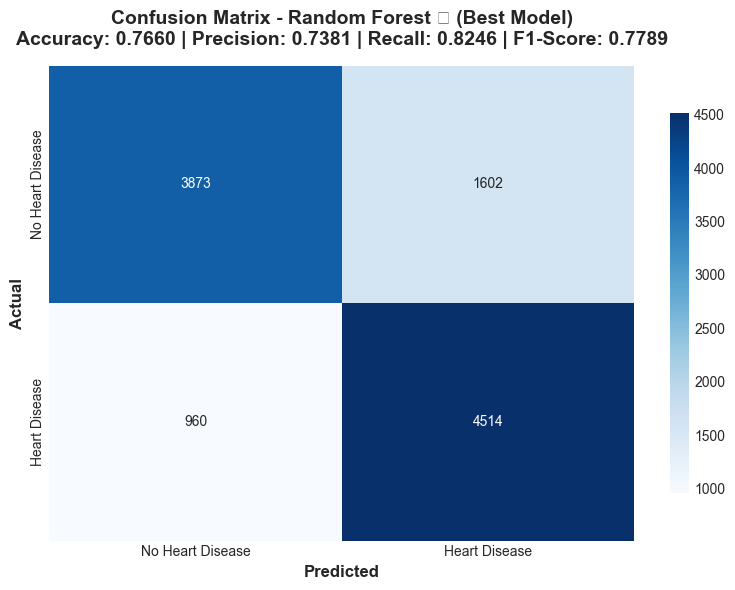

✓ Confusion matrix visualized for: Random Forest


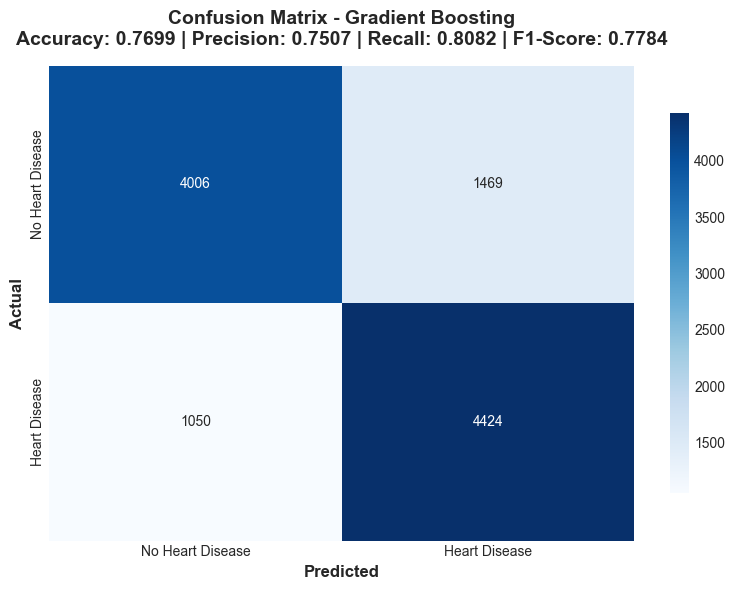

✓ Confusion matrix visualized for: Gradient Boosting


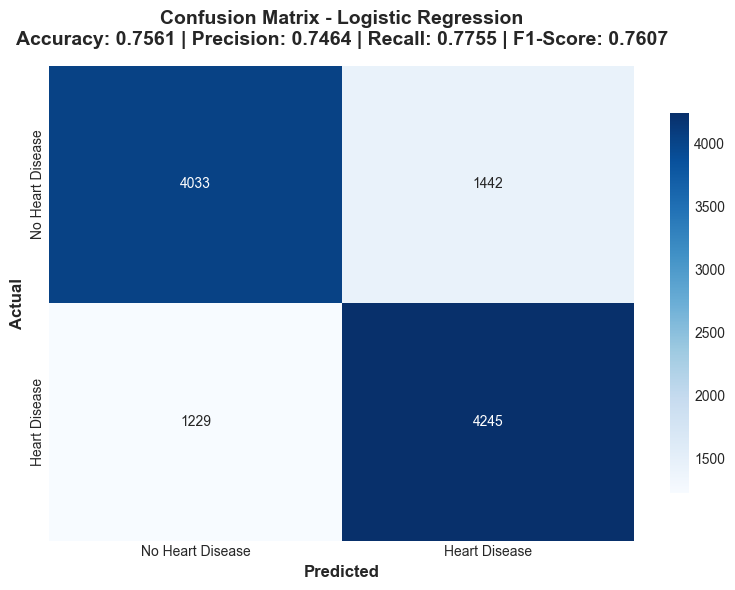

✓ Confusion matrix visualized for: Logistic Regression


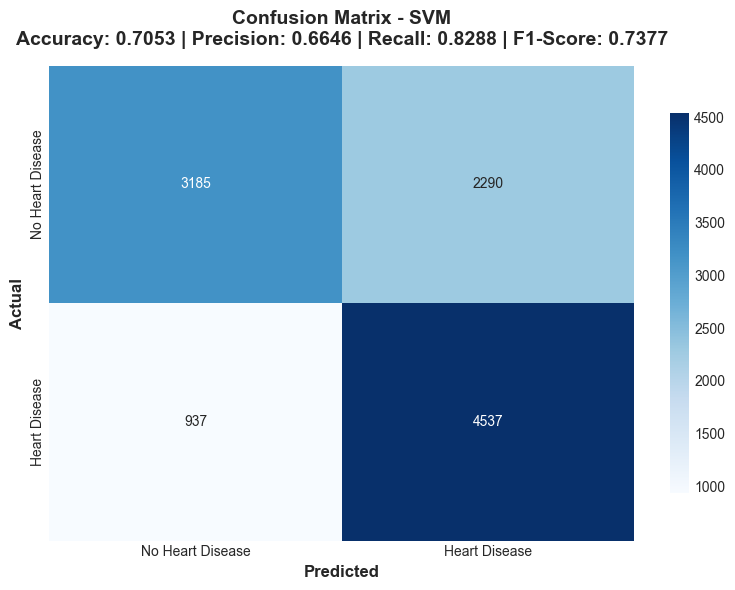

✓ Confusion matrix visualized for: SVM


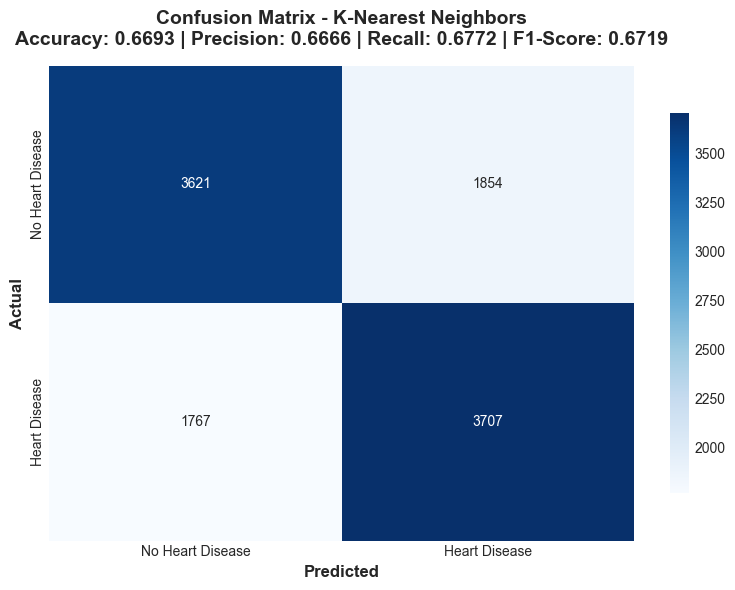

✓ Confusion matrix visualized for: K-Nearest Neighbors


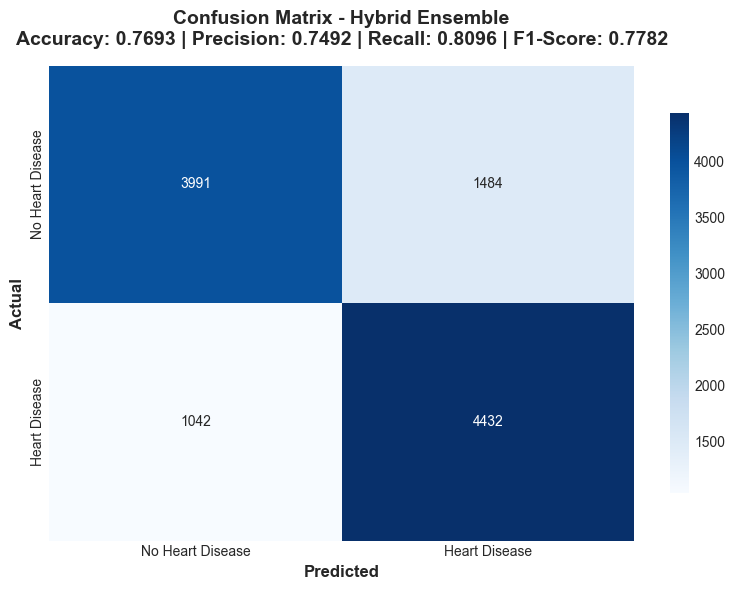

✓ Confusion matrix visualized for: Hybrid Ensemble

✓ All 6 confusion matrices visualized!
⭐ Best model: Random Forest


In [ ]:
# Visualize Confusion Matrices for All 6 Models (Separate Images)
print("=" * 70)
print("CONFUSION MATRICES FOR ALL MODELS")
print("=" * 70)

# Get all model names
model_names = list(results.keys())

# Create a separate figure for each model
for model_name in model_names:
    # Create a new figure for each model
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, results[model_name]['predictions'])
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Heart Disease', 'Heart Disease'],
                yticklabels=['No Heart Disease', 'Heart Disease'],
                cbar_kws={'shrink': 0.8})
    
    # Calculate metrics for display
    accuracy = results[model_name]['accuracy']
    precision = results[model_name]['precision']
    recall = results[model_name]['recall']
    f1 = results[model_name]['f1']
    
    # Set title with metrics
    title = f'Confusion Matrix - {model_name}\nAccuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}'
    if model_name == best_model_name:
        title = f'Confusion Matrix - {model_name} ⭐ (Best Model)\nAccuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}'
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Confusion matrix visualized for: {model_name}")

print(f"\n✓ All {len(model_names)} confusion matrices visualized!")
print(f"⭐ Best model: {best_model_name}")
